# CardioIA Fase 4 — Notebook 2: Modelagem (Parte 2)

**CNN do zero** + **Transfer Learning (MobileNetV2 com fine-tuning)** + avaliação + **Grad-CAM**.

> ⚠️ **Protótipo acadêmico (FIAP).** Não é dispositivo médico, não foi validado clinicamente e não deve ser usado para diagnóstico real.

Cobre dois critérios da rubrica: *CNN do zero* (seção 4) e *Transfer Learning* (seção 5).
Métricas da rubrica (acurácia, matriz de confusão, precisão, recall, F1) + AUC-ROC/AUC-PR
(rigor complementar para classe desbalanceada). Rode no **Kaggle GPU** com o dataset NIH +
o dataset de pesos `diogozequini/mnv2-imagenet-notop-weights` anexados.


In [1]:
# ===== CardioIA Fase 4 - Etapa 2: CNN do zero + Transfer Learning (MobileNetV2) =====
# Otimizado para CPU (sem depender de GPU). Dataset nih-chest-xrays/data + pesos anexados.
# Saidas em /kaggle/working.
import json, os, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)
import tensorflow as tf
from tensorflow.keras import layers, models

SEED = 565535
IMG = (224, 224)
BATCH = 32
OUT = Path("/kaggle/working")
CLASSES = ["No Finding", "Cardiomegaly"]

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED); tf.keras.utils.set_random_seed(SEED)
print("TF:", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

In [2]:
# ---------- 1) Subset + split por paciente (mesma logica/seed da Etapa 1) ----------
INPUT = Path("/kaggle/input")
csv = next(INPUT.rglob("Data_Entry_2017.csv"))
df = pd.read_csv(csv)
df["Patient Age"] = pd.to_numeric(df["Patient Age"], errors="coerce")
df = df[df["Patient Age"].between(0, 120)].copy()
tem = df["Finding Labels"].str.split("|").map(lambda x: "Cardiomegaly" in x)
pos = df[tem].copy(); pos["target"] = 1
neg = df[df["Finding Labels"].eq("No Finding")].copy(); neg["target"] = 0
N = min(1200, len(pos), len(neg))
sub = pd.concat([pos.sample(N, random_state=SEED), neg.sample(N, random_state=SEED)], ignore_index=True)
sub = sub.sample(frac=1, random_state=SEED).reset_index(drop=True)
g1 = GroupShuffleSplit(1, train_size=0.70, random_state=SEED)
tr_i, tm_i = next(g1.split(sub, groups=sub["Patient ID"]))
train, tmp = sub.iloc[tr_i].copy(), sub.iloc[tm_i].copy()
g2 = GroupShuffleSplit(1, train_size=0.50, random_state=SEED + 1)
v_i, t_i = next(g2.split(tmp, groups=tmp["Patient ID"]))
val, test = tmp.iloc[v_i].copy(), tmp.iloc[t_i].copy()
for d, s in [(train, "train"), (val, "val"), (test, "test")]:
    d["split"] = s
mani = pd.concat([train, val, test], ignore_index=True)
S = {s: set(g["Patient ID"]) for s, g in mani.groupby("split")}
assert not (S["train"] & S["val"]) and not (S["train"] & S["test"]) and not (S["val"] & S["test"])
paths = {p.name: str(p) for p in INPUT.rglob("*.png")}
for d in (train, val, test):
    d["fp"] = d["Image Index"].map(paths); d.dropna(subset=["fp"], inplace=True)
mani["fp"] = mani["Image Index"].map(paths); mani.dropna(subset=["fp"], inplace=True)
mani.to_csv(OUT / "data_manifest.csv", index=False)
print("Split (imgs):", len(train), len(val), len(test))

y_tr = train["target"].values.astype("float32")
y_va = val["target"].values.astype("float32")
y_te = test["target"].values.astype(int)

In [3]:
# ---------- 2) Pipelines tf.data (raw 0-255; preprocessing fica DENTRO do modelo) ----------
def decode(fp, y):
    img = tf.image.resize(tf.io.decode_png(tf.io.read_file(fp), channels=3), IMG)
    return tf.cast(img, tf.float32), tf.cast(y, tf.float32)

def make_ds(d, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((d["fp"].values, y))
    ds = ds.map(decode, tf.data.AUTOTUNE).cache()
    if shuffle:
        ds = ds.shuffle(len(d), seed=SEED)
    return ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

ds_tr = make_ds(train, y_tr, True)
ds_va = make_ds(val, y_va)
ds_te = make_ds(test, y_te.astype("float32"))

aug = models.Sequential([layers.RandomFlip("horizontal", seed=SEED),
                         layers.RandomRotation(0.03, seed=SEED),
                         layers.RandomZoom(0.05, seed=SEED)], name="augment")

In [4]:
# ---------- 3) Avaliacao reutilizavel ----------
def evaluate(scores, name, thr=0.5):
    pred = (scores >= thr).astype(int)
    m = {"modelo": name, "accuracy": float(accuracy_score(y_te, pred)),
         "precision": float(precision_score(y_te, pred, zero_division=0)),
         "recall": float(recall_score(y_te, pred, zero_division=0)),
         "f1": float(f1_score(y_te, pred, zero_division=0)),
         "auc_roc": float(roc_auc_score(y_te, scores)),
         "auc_pr": float(average_precision_score(y_te, scores)), "threshold": thr}
    print(f"\n=== {name} ===")
    for k in ["accuracy", "precision", "recall", "f1", "auc_roc", "auc_pr"]:
        print(f"{k:9s}: {m[k]:.4f}")
    print(classification_report(y_te, pred, target_names=CLASSES, zero_division=0))
    slug = name.lower().replace(" ", "_")
    ConfusionMatrixDisplay(confusion_matrix(y_te, pred), display_labels=CLASSES).plot(cmap="Blues", colorbar=False)
    plt.title(f"Matriz de Confusao - {name}"); plt.tight_layout(); plt.savefig(OUT / f"confusion_{slug}.png", dpi=130); plt.close()
    fpr, tpr, _ = roc_curve(y_te, scores)
    plt.plot(fpr, tpr, label=f"AUC-ROC={m['auc_roc']:.3f}"); plt.plot([0, 1], [0, 1], "--", c="gray")
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC - {name}"); plt.legend(); plt.tight_layout()
    plt.savefig(OUT / f"roc_{slug}.png", dpi=130); plt.close()
    pr, rc, _ = precision_recall_curve(y_te, scores)
    plt.plot(rc, pr, label=f"AUC-PR={m['auc_pr']:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precisao"); plt.title(f"PR - {name}"); plt.legend(); plt.tight_layout()
    plt.savefig(OUT / f"pr_{slug}.png", dpi=130); plt.close()
    return m

metrics = []
cb = lambda: [tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)]

In [5]:
# ---------- 4) CNN do zero (downsampling agressivo -> barato em CPU) ----------
scratch = models.Sequential([
    layers.Input((224, 224, 3)), aug, layers.Rescaling(1. / 255),
    layers.Conv2D(16, 3, strides=2, activation="relu", padding="same"), layers.BatchNormalization(), layers.MaxPool2D(),
    layers.Conv2D(32, 3, activation="relu", padding="same"), layers.BatchNormalization(), layers.MaxPool2D(),
    layers.Conv2D(64, 3, activation="relu", padding="same", name="last_conv"), layers.BatchNormalization(), layers.MaxPool2D(),
    layers.GlobalAveragePooling2D(), layers.Dropout(0.4), layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
], name="cnn_scratch")
scratch.compile("adam", "binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
h1 = scratch.fit(ds_tr, validation_data=ds_va, epochs=18, callbacks=cb(), verbose=2)
plt.plot(h1.history["loss"], label="train"); plt.plot(h1.history["val_loss"], label="val")
plt.legend(); plt.title("Curva treino - CNN do zero"); plt.tight_layout(); plt.savefig(OUT / "history_cnn.png", dpi=130); plt.close()
metrics.append(evaluate(scratch.predict(ds_te, verbose=0).ravel(), "CNN do zero"))
scratch.save(OUT / "cnn_scratch.keras")

In [6]:
# ---------- 5) Transfer Learning: features pre-computadas (rapido) + fine-tuning curto ----------
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
wpath = next(Path("/kaggle/input").rglob("mobilenet_v2*no_top.h5"))
print("Pesos MobileNetV2:", wpath)
base = MobileNetV2(include_top=False, weights=None, input_shape=(224, 224, 3)); base.load_weights(str(wpath))
base.trainable = False

# 5a) extrator congelado -> features (1 passada apenas)
fe_in = layers.Input((224, 224, 3))
fe = layers.Lambda(preprocess_input, name="mnv2_preprocess")(fe_in)
fe = base(fe, training=False)
fe = layers.GlobalAveragePooling2D()(fe)
feat_model = models.Model(fe_in, fe, name="feat_extractor")
def ordered(d):
    return tf.data.Dataset.from_tensor_slices(d["fp"].values).map(
        lambda fp: tf.cast(tf.image.resize(tf.io.decode_png(tf.io.read_file(fp), channels=3), IMG), tf.float32)
    ).batch(BATCH).prefetch(tf.data.AUTOTUNE)
print("Extraindo features (frozen)...")
Xtr = feat_model.predict(ordered(train), verbose=0)
Xva = feat_model.predict(ordered(val), verbose=0)
Xte = feat_model.predict(ordered(test), verbose=0)

# 5b) head sobre features
head = models.Sequential([layers.Input((Xtr.shape[1],)), layers.Dropout(0.3),
                          layers.Dense(1, activation="sigmoid", name="clf")], name="head")
head.compile("adam", "binary_crossentropy", metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
head.fit(Xtr, y_tr, validation_data=(Xva, y_va), epochs=40, callbacks=cb(), verbose=2)
metrics.append(evaluate(head.predict(Xte, verbose=0).ravel(), "Transfer frozen"))

# 5c) modelo completo p/ fine-tuning + gradcam + deploy (copia pesos do head)
inp = layers.Input((224, 224, 3))
x = aug(inp)
x = layers.Lambda(preprocess_input, name="mnv2_preprocess2")(x)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation="sigmoid", name="clf")(x)
transfer = models.Model(inp, out, name="transfer_mobilenetv2")
transfer.get_layer("clf").set_weights(head.get_layer("clf").get_weights())
# fine-tuning: descongela ultimas 20 camadas, LR baixo, poucas epocas (CPU)
base.trainable = True
for l in base.layers[:-20]:
    l.trainable = False
transfer.compile(tf.keras.optimizers.Adam(1e-5), "binary_crossentropy",
                 metrics=["accuracy", tf.keras.metrics.AUC(name="auc")])
h3 = transfer.fit(ds_tr, validation_data=ds_va, epochs=4, callbacks=cb(), verbose=2)
plt.plot(h3.history["loss"], label="train"); plt.plot(h3.history["val_loss"], label="val")
plt.legend(); plt.title("Curva fine-tuning - Transfer"); plt.tight_layout(); plt.savefig(OUT / "history_transfer.png", dpi=130); plt.close()
metrics.append(evaluate(transfer.predict(ds_te, verbose=0).ravel(), "Transfer fine-tuning"))
transfer.save(OUT / "transfer_mobilenetv2.keras")

In [7]:
# ---------- 6) Grad-CAM (MobileNetV2) em amostras de teste ----------
def gradcam(model, base_model, img_batch):
    gm = tf.keras.models.Model(model.inputs, [base_model.get_layer("out_relu").output, model.output])
    with tf.GradientTape() as tape:
        conv, pred = gm(img_batch); ch = pred[:, 0]
    grads = tape.gradient(ch, conv)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))
    hm = tf.squeeze(conv[0] @ pooled[..., None])
    return (tf.maximum(hm, 0) / (tf.reduce_max(hm) + 1e-8)).numpy()

ex = test[test["target"] == 1].head(4).reset_index(drop=True)
for i, row in ex.iterrows():
    raw = tf.image.resize(tf.io.decode_png(tf.io.read_file(row["fp"]), channels=3), IMG).numpy()
    hm = gradcam(transfer, base, raw[None].astype("float32"))
    hm_r = tf.image.resize(hm[..., None], IMG).numpy().squeeze()
    overlay = (0.4 * cm.jet(hm_r)[..., :3] * 255 + 0.6 * raw).astype("uint8")
    fig, ax = plt.subplots(1, 2, figsize=(7, 4))
    ax[0].imshow(raw.astype("uint8")); ax[0].set_title("Raio-X"); ax[0].axis("off")
    ax[1].imshow(overlay); ax[1].set_title("Grad-CAM (Cardiomegaly)"); ax[1].axis("off")
    plt.tight_layout(); plt.savefig(OUT / f"gradcam_{i+1}.png", dpi=130); plt.close()
print("Grad-CAM salvo.")

TF: 2.19.0 | GPUs: []
Split (imgs): 1707 348 345
Epoch 1/18
54/54 - 45s - 831ms/step - accuracy: 0.5571 - auc: 0.5868 - loss: 0.6906 - val_accuracy: 0.4713 - val_auc: 0.4511 - val_loss: 0.6965
Epoch 2/18
54/54 - 22s - 402ms/step - accuracy: 0.6028 - auc: 0.6359 - loss: 0.6661 - val_accuracy: 0.5230 - val_auc: 0.4697 - val_loss: 0.6938
Epoch 3/18
54/54 - 22s - 402ms/step - accuracy: 0.6087 - auc: 0.6450 - loss: 0.6618 - val_accuracy: 0.5287 - val_auc: 0.5275 - val_loss: 0.6924
Epoch 4/18
54/54 - 22s - 399ms/step - accuracy: 0.6151 - auc: 0.6438 - loss: 0.6655 - val_accuracy: 0.5201 - val_auc: 0.6610 - val_loss: 0.7174
Epoch 5/18
54/54 - 41s - 754ms/step - accuracy: 0.6134 - auc: 0.6468 - loss: 0.6619 - val_accuracy: 0.5891 - val_auc: 0.6369 - val_loss: 0.6762
Epoch 6/18
54/54 - 22s - 399ms/step - accuracy: 0.6321 - auc: 0.6611 - loss: 0.6538 - val_accuracy: 0.5230 - val_auc: 0.6596 - val_loss: 0.6886
Epoch 7/18
54/54 - 22s - 400ms/step - accuracy: 0.6274 - auc: 0.6718 - loss: 0.6477 - v

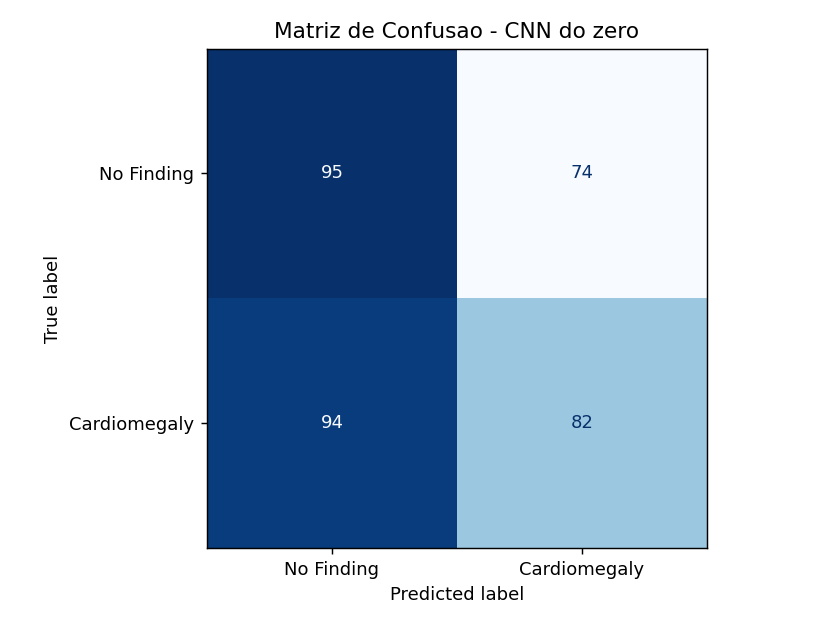

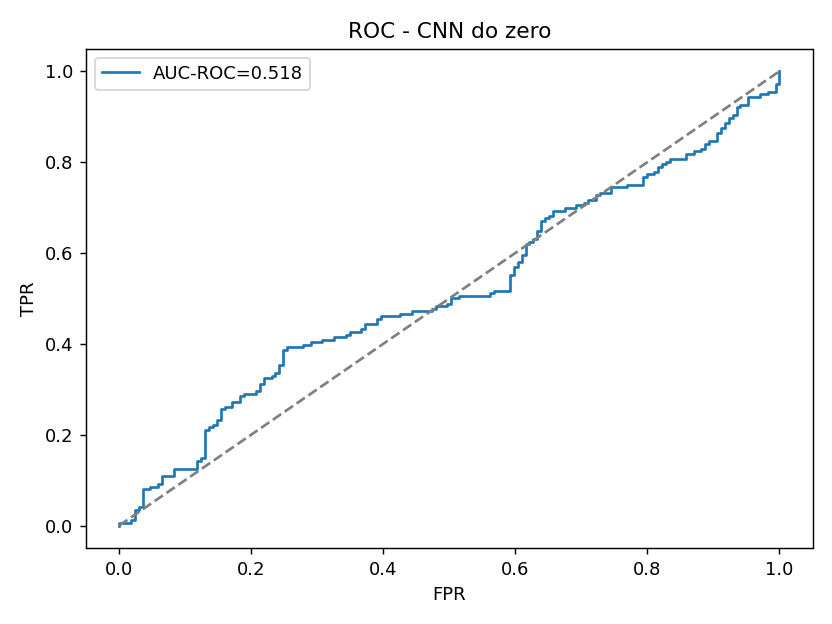

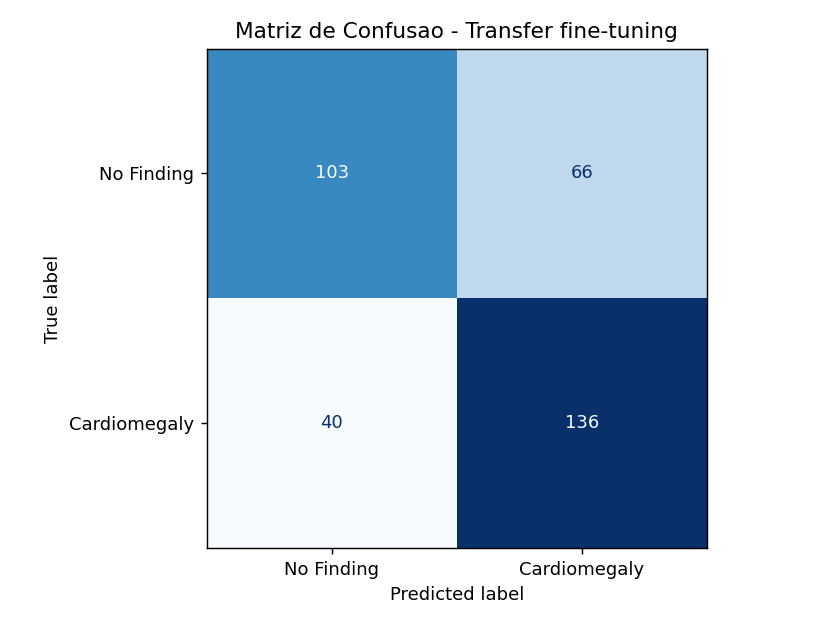

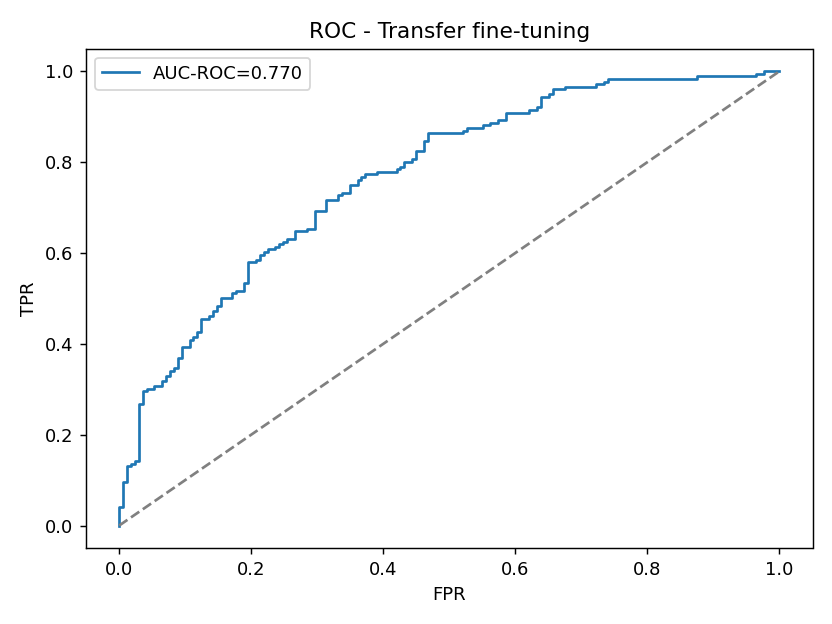

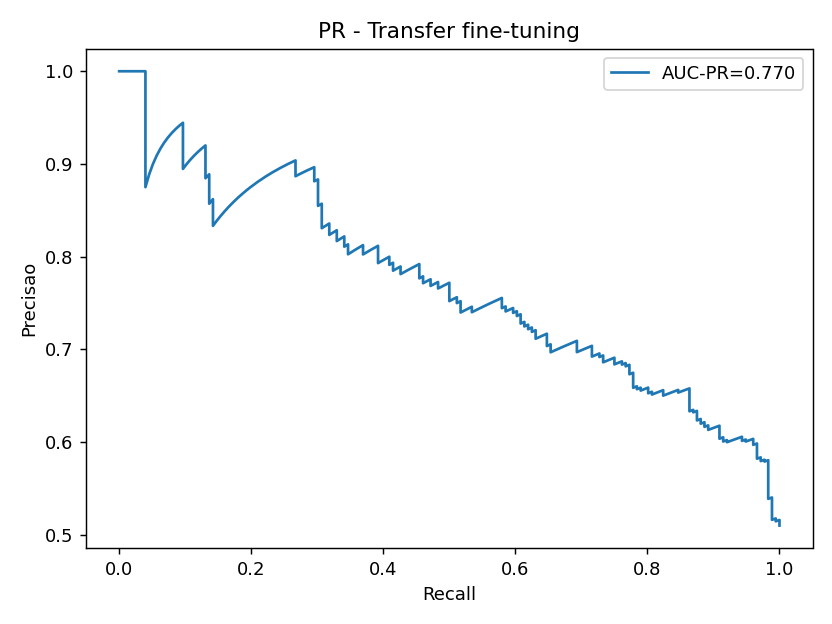

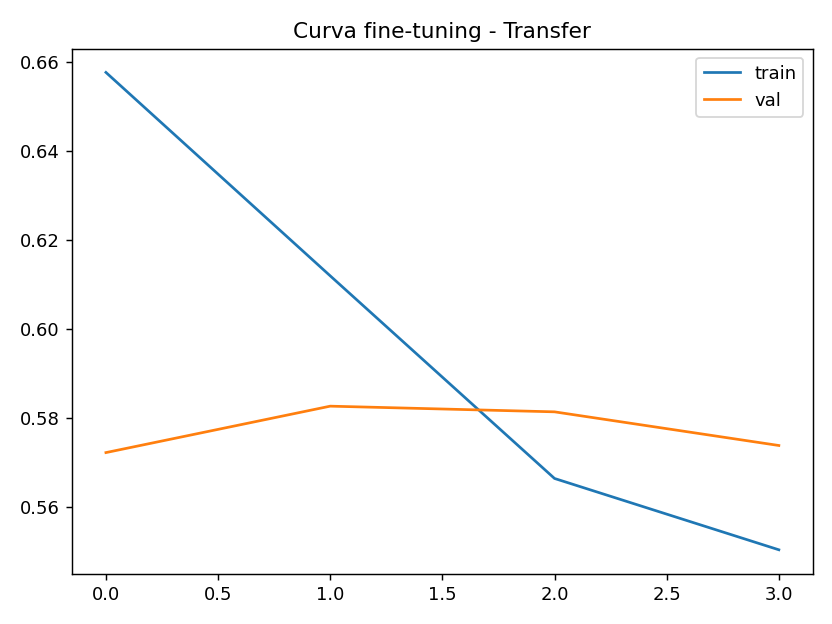

In [8]:
# ---------- 7) Config de preprocessamento (Flask) + tabela comparativa ----------
cfg = {"model_kind": "mobilenetv2", "img_size": list(IMG), "class_names": CLASSES,
       "preprocess_in_model": True, "last_conv_layer": "out_relu", "threshold": 0.5, "seed": SEED}
(OUT / "preprocess_config.json").write_text(json.dumps(cfg, indent=2), encoding="utf-8")
comp = pd.DataFrame(metrics)[["modelo", "accuracy", "precision", "recall", "f1", "auc_roc", "auc_pr"]]
comp.to_csv(OUT / "metricas_comparativo.csv", index=False)
(OUT / "metricas.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print("\n==== TABELA COMPARATIVA ====\n", comp.to_string(index=False))
print("\nArquivos:", [p.name for p in OUT.glob("*")]); print("OK.")

## Resultados (execução real no Kaggle — conjunto de teste, 345 imagens)

| Modelo | Acurácia | Precisão | Recall | F1 | AUC-ROC | AUC-PR |
|---|---:|---:|---:|---:|---:|---:|
| CNN do zero | 0.513 | 0.526 | 0.466 | 0.494 | 0.518 | 0.548 |
| Transfer (frozen) | 0.693 | 0.694 | 0.710 | 0.702 | 0.765 | 0.768 |
| **Transfer (fine-tuning)** | 0.693 | 0.673 | **0.773** | **0.720** | **0.770** | **0.770** |

A CNN do zero fica próxima do acaso (AUC ≈ 0.52); o Transfer Learning sobe para AUC ≈ 0.77 e o
fine-tuning melhora o recall (0.71 → 0.77). Matrizes de confusão, ROC/PR, curvas de treino e Grad-CAM
em `resultados/`.
